In [9]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Internship/Twitter_Data.csv')

print(df.head())

OSError: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/Internship/Twitter_Data.csv'

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
import os
print(os.listdir('/content/drive/MyDrive/Internship'))

['Week 1 Report.docx', 'archive.zip', 'My_Project', '.tmp.driveupload', 'sentimentdataset.csv', 'Twitter_Data.csv']


In [12]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Internship/Twitter_Data.csv')
print(df.head())

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


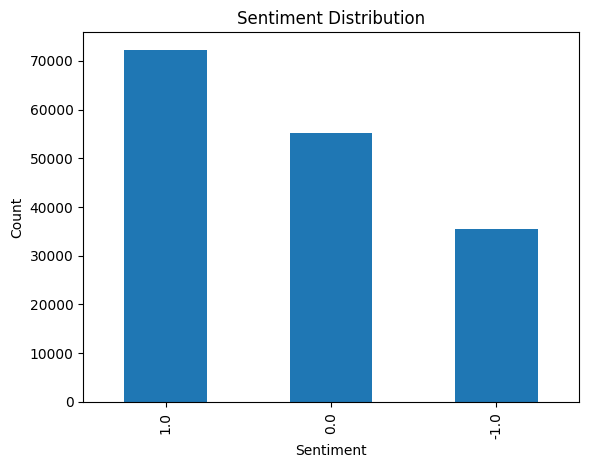

In [13]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [15]:
df = df.dropna()

In [16]:
import pandas as pd

# Load data
df = pd.read_csv('/content/drive/MyDrive/Internship/Twitter_Data.csv')

df = df[['clean_text', 'category']]
df = df.dropna()

print(df.head())

import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Clean text
def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['clean_text'] = df['clean_text'].apply(clean)

# Features & Labels
X = df['clean_text']
y = df['category']

# Convert text to numbers
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0
Accuracy: 0.9196171074430877


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
